In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [10]:
DATA_PATH = Path("../data/raw/allsides_balanced_news_headlines-texts.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21754, 7)


,Unnamed: 0,title,tags,heading,source,text,bias_rating
0,0,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",Chicago Gun Violence Spikes and Increasingly F...,New York Times (News),As Yasmin Miller drove home from a laundromat ...,left
1,1,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",‘Bullets just came from nowhere’: Fourth of Ju...,Chicago Tribune,As many Chicagoans were celebrating the Fourth...,center
2,2,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",Dozens of shootings across US mark bloody July...,New York Post (News),The nation’s 4th of July weekend was marred by...,right
3,3,Yellen Warns Congress of 'Economic Recession' ...,"['Janet Yellen', 'Debt Ceiling', 'Economic Pol...",Federal Government Will Run Out of Cash on Oct...,The Epoch Times,Treasury Secretary Janet Yellen on Tuesday war...,right
4,4,Yellen Warns Congress of 'Economic Recession' ...,"['Janet Yellen', 'Debt Ceiling', 'Economic Pol...",Yellen tells Congress that U.S. will run out o...,Washington Post,Treasury Secretary Janet Yellen on Tuesday tol...,left


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21754 entries, 0 to 21753
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   21754 non-null  int64
 1   title        21754 non-null  str  
 2   tags         21754 non-null  str  
 3   heading      21754 non-null  str  
 4   source       21746 non-null  str  
 5   text         21747 non-null  str  
 6   bias_rating  21754 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.2 MB


In [12]:
df.columns.tolist()

['Unnamed: 0', 'title', 'tags', 'heading', 'source', 'text', 'bias_rating']

In [14]:
df["bias_rating"].value_counts()

bias_rating
left      10275
right      7226
center     4253
Name: count, dtype: int64

In [16]:
df["bias_rating"].value_counts(normalize = True)*100

bias_rating
left      47.232693
right     33.216880
center    19.550428
Name: proportion, dtype: float64

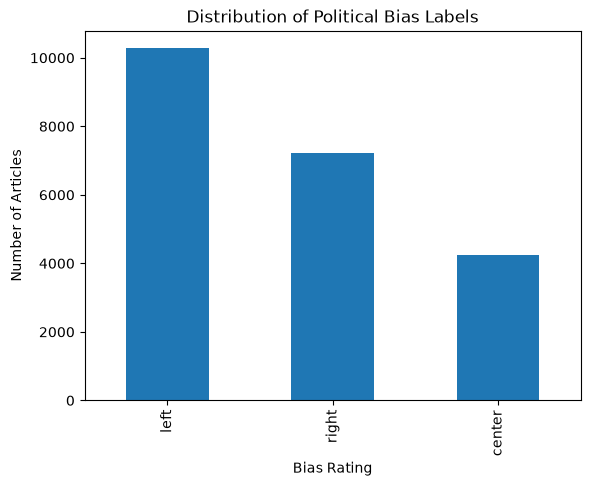

In [17]:
df["bias_rating"].value_counts().plot(
    kind="bar",
    title="Distribution of Political Bias Labels"
)

plt.xlabel("Bias Rating")
plt.ylabel("Number of Articles")
plt.show()

In [18]:
# It is observed that center is the minority class

In [26]:
#Missing values
df.isnull().sum()

Unnamed: 0     0
title          0
tags           0
heading        0
source         8
text           7
bias_rating    0
dtype: int64

In [27]:
missing = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing

source         0.036775
text           0.032178
Unnamed: 0     0.000000
tags           0.000000
title          0.000000
heading        0.000000
bias_rating    0.000000
dtype: float64

In [28]:
#Duplicates

print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [29]:
print("Duplicate texts:", df["text"].duplicated().sum())

Duplicate texts: 30


In [30]:
print(
    "Duplicate title + heading + text:",
    df.duplicated(subset=["title", "heading", "text"]).sum()
)

Duplicate title + heading + text: 5


In [31]:
#Inspect the labels and sources together

pd.crosstab(
    df["source"],
    df["bias_rating"]
)

bias_rating,center,left,right
source,,,
AARP,2,0,0
ABC News (Online),0,193,0
ACLU,0,2,0
AZ Central,3,0,0
Aaron Carroll,1,0,0
...,...,...,...
Yahoo! The 360,1,0,0
YouTube,1,0,0
Zack Beauchamp,0,1,0


In [32]:
source_counts = df["source"].value_counts()

source_counts.head(20)

source
Fox News (Online News)        2032
CNN (Online News)             1628
Washington Post               1257
New York Times (News)         1227
Washington Times               950
The Hill                       880
Wall Street Journal (News)     854
HuffPost                       747
Politico                       711
Washington Examiner            706
NPR (Online News)              638
USA TODAY                      637
Reuters                        622
New York Post (News)           462
Townhall                       455
Associated Press               402
National Review                383
NBC News (Online)              358
BBC News                       350
Newsmax (News)                 344
Name: count, dtype: int64

In [33]:
print("Number of unique sources:", df["source"].nunique())

Number of unique sources: 464


In [34]:
# Article Length
df["text_length"] = df["text"].fillna("").str.len()

df["text_length"].describe()

count    21754.000000
mean       413.298979
std        177.541703
min          0.000000
25%        232.000000
50%        509.000000
75%        564.000000
max        821.000000
Name: text_length, dtype: float64

In [35]:
df["word_count"] = (
    df["text"]
    .fillna("")
    .str.split()
    .str.len()
)

df["word_count"].describe()

count    21754.000000
mean        66.273237
std         28.387571
min          0.000000
25%         37.000000
50%         86.000000
75%         90.000000
max        125.000000
Name: word_count, dtype: float64

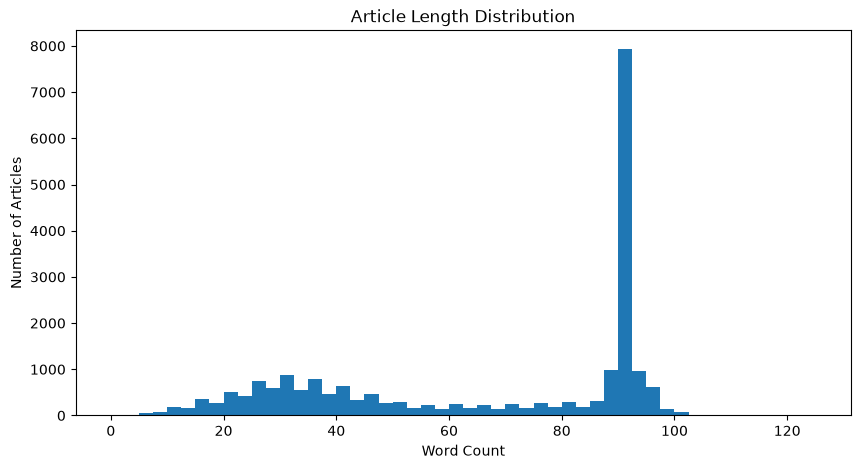

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.title("Article Length Distribution")

plt.show()

In [37]:
#Look at actual examples

pd.set_option("display.max_colwidth", 300)

df[
    ["title", "heading", "source", "bias_rating", "text"]
].sample(5, random_state=42)

,title,heading,source,bias_rating,text
13167,Trial Begins for Former Officer Charged With George Floyd's Death,Derek Chauvin trial and George Floyd's death: Live updates,NBC News (Online),left,"Former Minneapolis Police Officer Derek Chauvin's trial began Monday morning. Chauvin faces three charges, including second-degree murder, in the death of George Floyd.\nFloyd, a Black man, died May 25 after Chauvin, a white 19-year veteran of the department, pressed his knee into Floyd's neck f..."
4068,Democratic Platform,Democratic platform focuses on fixing the economy,Townhall,right,Democrats unveiled a party platform at their national convention Monday that echoes President Barack Obama's call for higher taxes on wealthier Americans while backing same-sex marriage and abortion rights.
9857,FDA Authorizes Updated COVID-19 Booster Shots for Expected Fall Omicron Wave,Omicron-specific vaccine boosters get FDA sign-off,The Verge,left,COVID-19 vaccines designed to target the omicron variant have just been authorized by the Food and Drug Administration. Both Pfizer / BioNTech and Moderna got the FDA’s sign-off for their booster doses of the reformulated shot. This is the first update to COVID-19 vaccines to be authorized in th...
20210,Flake Donates to Doug Jones in Alabama Senate Race,Annoying to the End — Jeff Flake Publicly Writes Check to Roy Moore’s Challenger,The American Spectator,right,This guy. Sen. Jeff Flake (R-AZ) is being unceremoniously run out of office after one term because he so utterly failed his constituents in my native state of Arizona.
7655,How Does Oklahoma's Abortion Ban Strengthen Efforts Against Roe v Wade?,"Oklahoma's new abortion law doesn't even pretend to adhere to Roe, setting up a showdown",St. Louis Post-Dispatch,center,"In the game of up-the-ante that Republican-controlled states are playing in their zeal to eradicate abortion rights, Oklahoma took the lead this week. Its new law doesn’t bother with heartbeat standards or clever enforcement mechanisms but just says it outright: Any doctor who performs any abort..."


In [38]:
for label in ["left", "center", "right"]:
    print("\n" + "=" * 80)
    print("LABEL:", label.upper())
    print("=" * 80)

    sample = df[df["bias_rating"] == label].sample(
        2,
        random_state=42
    )

    for _, row in sample.iterrows():
        print("\nSource:", row["source"])
        print("Heading:", row["heading"])
        print("Text:", row["text"][:1000])


LABEL: LEFT

Source: Politico
Heading: Joni Ernst: ‘Very offended’ by Tom Harkin
Text: Iowan GOP Senate candidate Joni Ernst responded on Monday that she was “very offended” by Sen. Tom Harkin’s comments comparing her looks to Taylor Swift.
“I was very offended that Sen. Harkin would say that, I think it’s unfortunate that he and many in their party believe that you can’t be a real woman if you’re conservative and female,” Ernst said to “Fox & Friends.”

Source: Al Jazeera
Heading: COVID: US life expectancy drops, Black and Latinos hardest hit
Text: Life expectancy in the United States dropped a staggering one year during the first half of 2020 as COVID-19 caused its first wave of deaths that disproportionately affected people of colour, according to a new report (PDF) by the US Centers for Disease Control and Prevention (CDC) released on Thursday.
“This is a huge decline,” Robert Anderson, who oversees the numbers for the CDC, told the Associated Press. “You have to go back to World 

In [39]:
df.shape
df["bias_rating"].value_counts()
df.isnull().sum()
df["text"].duplicated().sum()
df["source"].nunique()
df["word_count"].describe()

count    21754.000000
mean        66.273237
std         28.387571
min          0.000000
25%         37.000000
50%         86.000000
75%         90.000000
max        125.000000
Name: word_count, dtype: float64

In [40]:
df[df["word_count"] == 0][
    ["title", "tags", "heading", "source", "text", "bias_rating"]
]

,title,tags,heading,source,text,bias_rating
4009,POTUS Starts Tweeting,"['White House', 'Politics']",President Obama Is Fired Up and Ready to Tweet,New York Times (News),NaN,left
8568,Biden Announces Release of 15 Million More Oil Barrels from Reserve,"['Energy', 'Oil', 'Joe Biden', 'OPEC', 'Gas Prices', 'Inflation']",White House Signals ‘Significant’ Drawdowns From Strategic Reserve Beyond 180 Million Oil Barrels,The Epoch Times,NaN,right
9285,De Blasio Under Fire,['Violence In America'],NYPD Officers Turn Their Back to Mayor de Blasio,Townhall,NaN,right
11289,NSA Mined Internet Data,"['NSA', 'Defense And Security']","Massive Government Surveillance Program Exposed, All Americans Affected",Townhall,NaN,right
11371,Obama Offers Israel Aid Before Romney Visit,"['Presidential Elections', 'Elections']",Obama sends aid to Israel ahead of Romney visit,Fox News (Online News),NaN,right
18436,Suspicious Packages Sent To Hillary Clinton and Barack Obama,['Polarization'],Explosive Devices Found in Mail Sent to Hillary Clinton and Obama,New York Times (News),NaN,left
20495,Zelenskyy Visits City Retaken by Ukrainian Forces Amid Counteroffensive,"['World', 'Ukraine War', 'Russia']",Russians Leave Behind Huge Arsenals of Ammunition While Retreating,Newsweek,NaN,center


In [41]:
print("Empty articles:", (df["word_count"] == 0).sum())
print("Articles < 10 words:", (df["word_count"] < 10).sum())
print("Articles < 20 words:", (df["word_count"] < 20).sum())

Empty articles: 7
Articles < 10 words: 137
Articles < 20 words: 1119


In [42]:
df.groupby("bias_rating")["word_count"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
bias_rating,,,,,
center,4253,70.836116,90.0,0,125
left,10275,64.112993,78.0,0,115
right,7226,66.659424,85.0,0,110


In [44]:
df[df["word_count"] == 0]["heading"].isna().sum()

np.int64(0)

In [45]:
df[df["word_count"] == 0]["heading"].str.len()

4009     46
8568     97
9285     48
11289    71
11371    47
18436    65
20495    66
Name: heading, dtype: int64

In [46]:
df["model_text"] = (
    df["heading"].fillna("") + " " +
    df["text"].fillna("")
).str.strip()

In [47]:
df["model_text"].isna().sum()

np.int64(0)

In [48]:
df["model_text"].str.len().describe()

count    21754.000000
mean       481.628850
std        181.701637
min         46.000000
25%        299.000000
50%        571.000000
75%        636.000000
max        876.000000
Name: model_text, dtype: float64

In [49]:
df["model_word_count"] = (
    df["model_text"]
    .str.split()
    .str.len()
)

df["model_word_count"].describe()

count    21754.000000
mean        76.836352
std         28.998166
min          8.000000
25%         47.000000
50%         95.000000
75%        101.000000
max        132.000000
Name: model_word_count, dtype: float64

In [50]:
#Find genuinely unusable articles
df[df["model_word_count"] == 0][
    ["title", "heading", "source", "text", "bias_rating"]
]

,title,heading,source,text,bias_rating


In [51]:
df.groupby("bias_rating")["model_word_count"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
bias_rating,,,,,,
center,4253,80.930637,98.0,28.580688,9,132
left,10275,74.641363,88.0,29.409531,8,128
right,7226,77.547744,94.0,28.352795,8,126


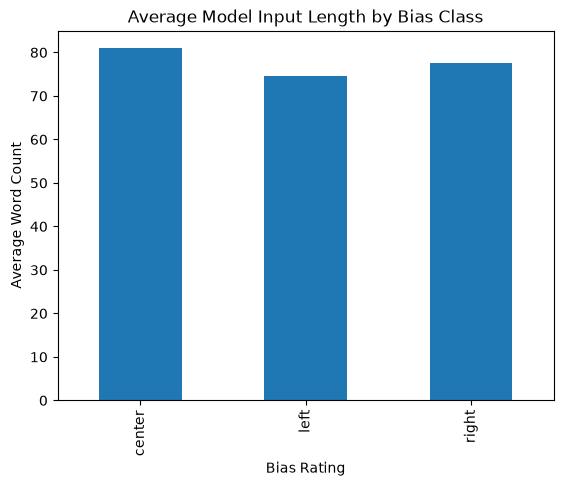

In [52]:
df.groupby("bias_rating")["model_word_count"].mean().plot(
    kind="bar",
    title="Average Model Input Length by Bias Class"
)

plt.xlabel("Bias Rating")
plt.ylabel("Average Word Count")
plt.show()

In [53]:
source_distribution = (
    df["source"]
    .value_counts()
    .to_frame("article_count")
)

source_distribution.head(20)

,article_count
source,
Fox News (Online News),2032
CNN (Online News),1628
Washington Post,1257
New York Times (News),1227
Washington Times,950
The Hill,880
Wall Street Journal (News),854
HuffPost,747
Politico,711


In [54]:
print("Unique sources:", df["source"].nunique())

Unique sources: 464


In [55]:
pd.crosstab(
    df["source"],
    df["bias_rating"],
    normalize="index"
).head(20)

bias_rating,center,left,right
source,,,
AARP,1.0,0.0,0.0
ABC News (Online),0.0,1.0,0.0
ACLU,0.0,1.0,0.0
AZ Central,1.0,0.0,0.0
Aaron Carroll,1.0,0.0,0.0
Above The Law,0.0,1.0,0.0
Accuracy in Media,0.0,0.0,1.0
Al Jazeera,0.0,1.0,0.0
Albuquerque Journal,1.0,0.0,0.0


In [56]:
# Source distribution by political bias
source_bias = pd.crosstab(
    df["source"],
    df["bias_rating"],
    normalize="index"
).round(3)

source_bias["total_articles"] = df["source"].value_counts()

source_bias.sort_values(
    "total_articles",
    ascending=False
).head(25)

bias_rating,center,left,right,total_articles
source,,,,
Fox News (Online News),0.0,0.0,1.0,2032
CNN (Online News),0.0,1.0,0.0,1628
Washington Post,0.0,1.0,0.0,1257
New York Times (News),0.0,1.0,0.0,1227
Washington Times,0.0,0.0,1.0,950
The Hill,1.0,0.0,0.0,880
Wall Street Journal (News),1.0,0.0,0.0,854
HuffPost,0.0,1.0,0.0,747
Politico,0.0,1.0,0.0,711


In [57]:
print("Unique event titles:", df["title"].nunique())
print(
    "Titles appearing more than once:",
    (df["title"].value_counts() > 1).sum()
)

df["title"].value_counts().head(15)

Unique event titles: 7263
Titles appearing more than once: 7261


title
French Election                                                                              6
Swing State Polls                                                                            6
Obama on Hillary’s Emails                                                                    6
July Jobs Report                                                                             6
Gun Control Debate Continues                                                                 6
CDC Says Vaccinated People Don't Have to Wear Masks Outside                                  6
Gun Violence Over Fourth of July Weekend                                                     3
Yellen Warns Congress of 'Economic Recession' if Debt Ceiling Isn't Raised                   3
Night 2: Christie on Hillary                                                                 3
Denying Abortion Medication Could Violate Civil Rights Laws, Biden Admin Tells Pharmacies    3
Mike Pence Defends Barring Pride Flags At US

In [58]:
title_counts = df["title"].value_counts()

print("Total rows:", len(df))
print("Unique titles:", df["title"].nunique())
print("Titles occurring once:", (title_counts == 1).sum())
print("Titles occurring 2+ times:", (title_counts >= 2).sum())
print("Titles occurring 3+ times:", (title_counts >= 3).sum())

print("\nTitle frequency distribution:")
print(title_counts.value_counts().sort_index().head(10))

Total rows: 21754
Unique titles: 7263
Titles occurring once: 2
Titles occurring 2+ times: 7261
Titles occurring 3+ times: 7212

Title frequency distribution:
count
1       2
2      49
3    7206
6       6
Name: count, dtype: int64


In [59]:
title_label_counts = (
    df.groupby("title")["bias_rating"]
    .nunique()
)

print(
    "Titles associated with multiple labels:",
    (title_label_counts > 1).sum()
)

Titles associated with multiple labels: 7222


In [60]:
# Inspect event titles with multiple articles and labels

title_analysis = (
    df.groupby("title")
    .agg(
        article_count=("title", "size"),
        unique_sources=("source", "nunique"),
        unique_labels=("bias_rating", "nunique"),
        sources=("source", lambda x: list(x)),
        labels=("bias_rating", lambda x: list(x))
    )
    .sort_values("article_count", ascending=False)
)

title_analysis.head(15)

,article_count,unique_sources,unique_labels,sources,labels
title,,,,,
French Election,6,6,3,"[National Review, Washington Post, BBC News, USA TODAY, Fox News (Online News), New York Times (News)]","[right, left, center, left, right, left]"
Gun Control Debate Continues,6,5,2,"[Fox News (Online News), CNN (Online News), Washington Post, New York Times (News), CNN (Online News), Washington Times]","[right, left, left, left, left, right]"
July Jobs Report,6,6,2,"[CNN (Online News), New York Times (News), Washington Times, NPR (Online News), The Daily Caller, Yahoo News]","[left, left, right, left, right, left]"
CDC Says Vaccinated People Don't Have to Wear Masks Outside,6,3,3,"[New York Post (News), Axios, CBS News (Online), New York Post (News), Axios, CBS News (Online)]","[right, center, left, right, center, left]"
Obama on Hillary’s Emails,6,6,3,"[Townhall, CNN (Online News), HuffPost, New York Times (News), The Blaze, Wall Street Journal (News)]","[right, left, left, left, right, center]"
Swing State Polls,6,5,3,"[Townhall, CNN (Online News), Wall Street Journal (News), The Hill, Vox, Townhall]","[right, left, center, center, left, right]"
YouTube Removes Project Veritas Video on Google Bias,3,3,3,"[AllSides, The American Spectator, Daily Beast]","[center, right, left]"
'Howdy Modi' Event Draws President Trump,3,3,3,"[CNBC, Washington Post, Washington Times]","[center, left, right]"
"'Social Distancing' as Americans Urged to Stay Home, Avoid Gathering",3,3,2,"[NBC News (Online), Associated Press, Townhall]","[left, left, right]"


In [61]:
event = "Gun Violence Over Fourth of July Weekend"

df.loc[
    df["title"] == event,
    ["title", "heading", "source", "bias_rating", "text"]
]

,title,heading,source,bias_rating,text
0,Gun Violence Over Fourth of July Weekend,Chicago Gun Violence Spikes and Increasingly Finds the Youngest Victims,New York Times (News),left,"As Yasmin Miller drove home from a laundromat in Chicago’s Englewood neighborhood last weekend, a gunman in another car peppered her red Hyundai sedan with bullets, grazing her head and striking her son, Sincere Gaston, in the chest. Sincere died in his car seat. He was 20 months old.\nOn June 2..."
1,Gun Violence Over Fourth of July Weekend,"‘Bullets just came from nowhere’: Fourth of July weekend gun violence kills at least 17, including 7-year-old-girl",Chicago Tribune,center,"As many Chicagoans were celebrating the Fourth of July with barbecues and after-dinner fireworks, relatives of Natalia Wallace were experiencing the worst day of their lives.\nThe 7-year-old girl was one of at least 80 people shot, at least 17 of those fatally, across the city during the violent..."
2,Gun Violence Over Fourth of July Weekend,Dozens of shootings across US mark bloody July 4th weekend,New York Post (News),right,"The nation’s 4th of July weekend was marred by the wrong kind of fireworks.\nA spate of shootings throughout the US left more than 150 people wounded and nearly two-dozen dead so far this weekend, including 67 gunshot victims in Chicago over a blood-splattered weekend, according to reports.\nPol..."


In [62]:
# Normalize text for comparison
df["normalized_text"] = (
    df["text"]
    .fillna("")
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Exact duplicate non-empty article texts
non_empty_text = df["normalized_text"].ne("")

print(
    "Duplicate non-empty article texts:",
    df.loc[non_empty_text, "normalized_text"].duplicated().sum()
)

Duplicate non-empty article texts: 24


In [63]:
duplicate_texts = (
    df.loc[non_empty_text]
    .groupby("normalized_text")
    .filter(lambda group: len(group) > 1)
)

duplicate_texts[
    ["title", "heading", "source", "bias_rating"]
].head(20)

,title,heading,source,bias_rating
404,Secretary of Defense James Mattis Resigns,"James Mattis quitting as defense secretary, cites differences with Trump",Washington Times,right
406,Secretary of Defense James Mattis Resigns,Mattis resigns after clash with Trump over troop withdrawal from Syria and Afghanistan,Washington Post,left
1994,Obama Will Leave Troops in Afghanistan,"Obama to keep 5,500 US troops in Afghanistan beyond 2016",Fox News (Online News),right
1996,Obama Will Leave Troops in Afghanistan,Obama Flips On Afghanistan Withdrawal Plan,HuffPost,left
3624,Back on the Campaign Trail,Obama Gears Up For Final Campaign Stretch After Hurricane Sandy Creates Headaches For Romney,HuffPost,left
3625,Back on the Campaign Trail,"Obama makes up for lost time after storm hiatus, Romney presses into Virginia",Fox News (Online News),right
4768,Second Year of Enrollments,Second Sign-Up Period For Obamacare Opens With Hopes And Fears,HuffPost,left
5712,Wisconsin in Play,Wisconsin center of Republican wave,Washington Times,right
5714,Wisconsin in Play,"Wisconsin finds itself at center of Republican wave with Walker, Ryan and Priebus",Washington Post,left
5949,House Approves Keystone,House Passes Bill to Approve Keystone XL Pipeline,Wall Street Journal (News),center


In [64]:
duplicate_text_groups = (
    df[df["normalized_text"].ne("")]
    .groupby("normalized_text")
    .filter(lambda group: len(group) > 1)
    .sort_values("normalized_text")
)

duplicate_text_groups[
    ["title", "heading", "source", "bias_rating"]
].to_string(index=False)

"                                                             title                                                                                      heading                     source bias_rating\n                                         Signups Surpass 1 Million                                            Federal Health Market Surpasses 1 Million Signups          NPR (Online News)        left\n                                         Signups Surpass 1 Million                                            Federal Health Market Surpasses 1 Million Signups          ABC News (Online)        left\n                                           Obama Inauguration 2013                           A tale of two terms: Obama's unfinished business and battles ahead          CNN (Online News)        left\n                                                  Inauguration Day                           A tale of two terms: Obama's unfinished business and battles ahead          CNN (Online News)        left\

In [65]:
duplicate_label_check = (
    duplicate_text_groups
    .groupby("normalized_text")
    .agg(
        copies=("bias_rating", "size"),
        labels=("bias_rating", "nunique"),
        sources=("source", "nunique")
    )
)

print("Duplicate groups:", len(duplicate_label_check))
print(
    "Groups with conflicting labels:",
    (duplicate_label_check["labels"] > 1).sum()
)

duplicate_label_check[
    duplicate_label_check["labels"] > 1
].head(10)

Duplicate groups: 24
Groups with conflicting labels: 18


,copies,labels,sources
normalized_text,,,
"china said on monday it would impose higher tariffs on a range of u.s. goods, striking back in its trade war with washington shortly after u.s. president donald trump warned it not to retaliate. china’s finance ministry said it plans to set import tariffs ranging from 5 percent to 25 percent on 5,140 u.s. products on a target list worth about $60 billion. it said the tariffs will take effect on june 1. the announcement came less than two hours after trump warned beijing not to retaliate after china said...",2,2,2
"china-based hackers are suspected of breaking into the computer networks of the u.s. government personnel office and stealing identifying information of at least 4 million federal workers, american officials said thursday.",2,2,2
christine blasey ford is seeking answers to a question that could define the rest of her life -- one that deterred her from going public weeks ago with sexual assault accusations against supreme court nominee brett kavanaugh.,2,2,2
"defense secretary james mattis, the last of a team president trump dubbed “my generals,” will step down early next year amid deepening rifts with the white house on crucial foreign policy matters, marking the departure of an original trump cabinet member and creating a leadership void at the pentagon at a critical time for the president at home and abroad.",2,2,2
"gaza residents cleared rubble and claimed victory on thursday, just hours after an egyptian-brokered truce between israel and gaza's hamas rulers ended the worst cross-border fighting in four years.",2,2,2
"more than 50 years after south carolina raised a confederate flag at its statehouse to protest the civil rights movement, the state is getting ready to remove the rebel banner.",2,2,2
"on a trip to afghanistan during president barack obama's first term, defense secretary robert gates was stunned to find a telephone line at the military's special operations headquarters that linked directly back to a top white house national security official. ""i had them tear it out while i was standing there,"" gates said earlier this month as he recounted his discovery. ""i told the commanders, 'if you get a call from the white house, you tell them to go to hell and call me.'"" to gates, the phone in kabul...",2,2,2
opposition from the senator from maine leaves republicans at least one vote short.,2,2,2
president barack obama dives back into campaigning after three days immersed in managing the federal response to the storm that battered the east coast.,2,2,2


In [ ]:
"""
### Conclusion

Exploratory Data Analysis (EDA) was performed on the Qbias / AllSides Balanced News dataset to understand its structure, label distribution, text characteristics, publisher distribution, and potential data-quality issues before model development.

The dataset contains **21,754 records and 7 columns**, including event titles, headlines, publisher names, article text, and political bias labels (`left`, `center`, and `right`). The class distribution is imbalanced, with the left class containing 10,275 records, the right class containing 7,226 records, and the center class containing 4,253 records. Therefore, macro-F1, per-class precision and recall, and the confusion matrix will be important evaluation metrics alongside accuracy.

Text-length analysis showed that the article text is relatively short, with a mean length of approximately 66 words and a median of 86 words. Seven records contain zero words in the article-text field, 137 contain fewer than 10 words, and 1,119 contain fewer than 20 words. Short records will not be removed solely because of their length, since political framing may also occur in headlines. Records with missing article text will be assessed using the availability of their headlines.

Publisher analysis revealed a strong association between the recorded publisher and its political bias label. Many publishers in the examined source distribution had articles assigned to only one label. This creates a risk of **source leakage**, where a model learns publisher-specific patterns instead of generalizable linguistic indicators of political framing.

Event-title analysis identified 7,263 unique titles, with most titles occurring multiple times. A total of 7,222 titles were associated with multiple bias labels, demonstrating that the dataset includes multiple perspectives on shared events. This creates an opportunity for comparative framing analysis but also introduces a risk of event-related leakage when splitting the data.

An exact-text comparison identified 24 groups of repeated non-empty article text, of which 18 groups contained conflicting bias labels. These cases require further investigation because repeated or identical text with different labels can affect model training and evaluation. Duplicate analysis will also be repeated using the combined headline-and-text input that the initial classifier will consume.

Based on these findings, preprocessing will retain the original dataset, preserve publisher and event metadata for analysis, construct a combined headline-and-text input, investigate empty records and duplicate content, and document any exclusions. The dataset will then be evaluated using both conventional stratified splitting and leakage-aware evaluation strategies, including source-disjoint and event-disjoint splits.

Overall, the EDA establishes the dataset's suitability for initial political-bias classification experiments while identifying important limitations involving class imbalance, source-label association, repeated events, and duplicate text. These issues must be addressed before drawing conclusions about the model's ability to generalize to unseen articles and publishers.
"""